In [1]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_rw, simulate_network_gp

0.19481142857142858


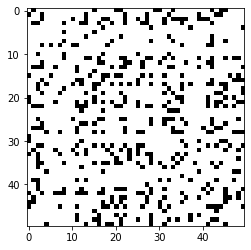

In [38]:
k_steps = 5

Y, X, probas_true = simulate_network_gp(
    n_nodes=50, n_time_steps=100 + k_steps, 
    density=0.2, random_state=32, length_scale=3)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

In [39]:
import os

out_dir = f'fase_data/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

np.savetxt(os.path.join(out_dir, 'time_points.npy'), np.linspace(0, 1, len(Y)))
for t in range(len(Y)):
    np.savetxt(os.path.join(out_dir, f'Y_{t+1}.npy'), Y[t].toarray())
    np.savetxt(os.path.join(out_dir, f'X_{t+1}.npy'), X[t])

In [40]:
! Rscript fase.R

Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var


── Column specification ────────────────────────────────────────────────────────
cols(
  X1 = col_double()
)

 [1]  4  6  8 10 12 14 16 18 20 22 24
[1] "q = 4 ngcv = -0.983872400743896"
[1] "q = 6 ngcv = -0.9840953488635"
[1] "q = 8 ngcv = -0.98323266482372"
[1] "q = 10 ngcv = -0.98237690368"
[1] "q = 12 ngcv = -0.981529010025238"
[1] "q = 14 ngcv = -0.980555604222972"
[1] "q = 16 ngcv = -0.979789518839123"
[1] "q = 18 ngcv = -0.979041816540141"
[1] "q = 20 ngcv = -0.978197108302972"
[1] "q = 22 ngcv = -0.977418939362185"
[1] "q = 24 ngcv = -0.97662387597347"
[1] 0.002286597
[1] 50 50
[1] 0.002370911
[1] 0.002411299
[1] 0.00249875
[1] 0.002632423
[1] 0.00281185


In [41]:
k_steps = 5

rdpg = DynamicRDPG(n_features=2, rw_order=2)
rdpg.sample(Y[:-k_steps], n_burnin=500, n_samples=500)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:10<00:00,  7.65it/s]


In [42]:
from scipy.linalg import orthogonal_procrustes

X_pred = rdpg.X_.copy()
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_pred[t], X[t])
    X_pred[t] = X_pred[t] @ R
    
#print(rdpg.auc_)
np.mean((X_pred - X[:-k_steps]) ** 2)

0.001930313019318249

In [45]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps).mean(axis=0)

for k in range(k_steps):
    y_predk = y_pred[k][subdiag]
    print(np.mean((probas_true[-(k+1)][subdiag] - y_predk) ** 2))

0.0022567938563675936
0.0021785874495583116
0.002238240250640005
0.002439034347331997
0.002783127986243519
